In [1]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

In [2]:
df = pd.read_csv("../bank_customer_survey.csv")

In [3]:
df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,0
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,0
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,0
3,47,blue,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,0
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,0


In [4]:
df.shape

(45211, 17)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        45211 non-null  int64 
 1   job        45211 non-null  object
 2   marital    45211 non-null  object
 3   education  45211 non-null  object
 4   default    45211 non-null  object
 5   balance    45211 non-null  int64 
 6   housing    45211 non-null  object
 7   loan       45211 non-null  object
 8   contact    45211 non-null  object
 9   day        45211 non-null  int64 
 10  month      45211 non-null  object
 11  duration   45211 non-null  int64 
 12  campaign   45211 non-null  int64 
 13  pdays      45211 non-null  int64 
 14  previous   45211 non-null  int64 
 15  poutcome   45211 non-null  object
 16  y          45211 non-null  int64 
dtypes: int64(8), object(9)
memory usage: 5.9+ MB


In [6]:
df.isnull().sum()

age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
pdays        0
previous     0
poutcome     0
y            0
dtype: int64

In [7]:
df.describe()

,age,balance,day,duration,campaign,pdays,previous,y
count,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000
mean,40.936210,1362.272058,15.806419,258.163080,2.763841,40.197828,0.580323,0.116985
std,10.618762,3044.765829,8.322476,257.527812,3.098021,100.128746,2.303441,0.321406
min,18.000000,-8019.000000,1.000000,0.000000,1.000000,-1.000000,0.000000,0.000000
25%,33.000000,72.000000,8.000000,103.000000,1.000000,-1.000000,0.000000,0.000000
50%,39.000000,448.000000,16.000000,180.000000,2.000000,-1.000000,0.000000,0.000000
75%,48.000000,1428.000000,21.000000,319.000000,3.000000,-1.000000,0.000000,0.000000
max,95.000000,102127.000000,31.000000,4918.000000,63.000000,871.000000,275.000000,1.000000


In [8]:
import warnings
warnings.filterwarnings("ignore")

<Axes: >

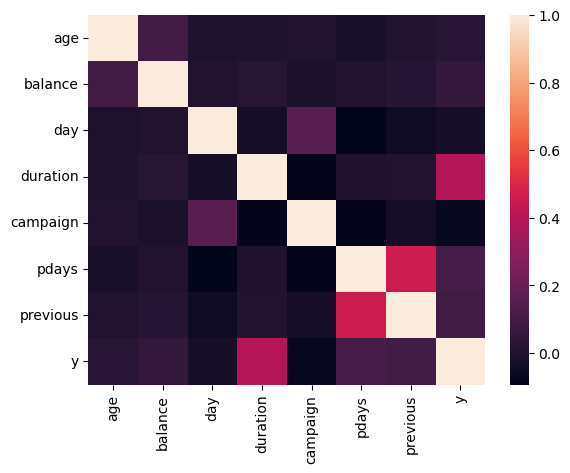

In [9]:
sns.heatmap(df.corr(numeric_only=True))

In [10]:
def cat_cols_unique_values(df):
    columns = df.select_dtypes(include=["object"]).columns
    for col in columns:
        print(f"{col} : {df[col].unique()}")
        print("number of unique: ",len(list(df[col].unique())))
        print("\n")

In [11]:
def is_cat_cols_have_unknown(df):
    cols = list()
    columns = df.select_dtypes(include=["object"]).columns
    for col in columns:
        if "unknown" in list(df[col].unique()):
            cols.append(col)
    return cols

In [12]:
cat_cols_unique_values(df)

job : ['management' 'technician' 'entrepreneur' 'blue' 'unknown' 'retired'
 'admin' 'services' 'self' 'unemployed' 'housemaid' 'student']
number of unique:  12


marital : ['married' 'single' 'divorced']
number of unique:  3


education : ['tertiary' 'secondary' 'unknown' 'primary']
number of unique:  4


default : ['no' 'yes']
number of unique:  2


housing : ['yes' 'no']
number of unique:  2


loan : ['no' 'yes']
number of unique:  2


contact : ['unknown' 'cellular' 'telephone']
number of unique:  3


month : ['may' 'jun' 'jul' 'aug' 'oct' 'nov' 'dec' 'jan' 'feb' 'mar' 'apr' 'sep']
number of unique:  12


poutcome : ['unknown' 'failure' 'other' 'success']
number of unique:  4




In [13]:
columns_have_unknown = is_cat_cols_have_unknown(df)

In [14]:
def cat_col_number_of_unknown(df,columns):
    for col in columns:
         print(f"{col} : {df[df[col]=="unknown"].shape[0]}")

In [15]:
cat_col_number_of_unknown(df, columns_have_unknown)

job : 288
education : 1857
contact : 13020
poutcome : 36959


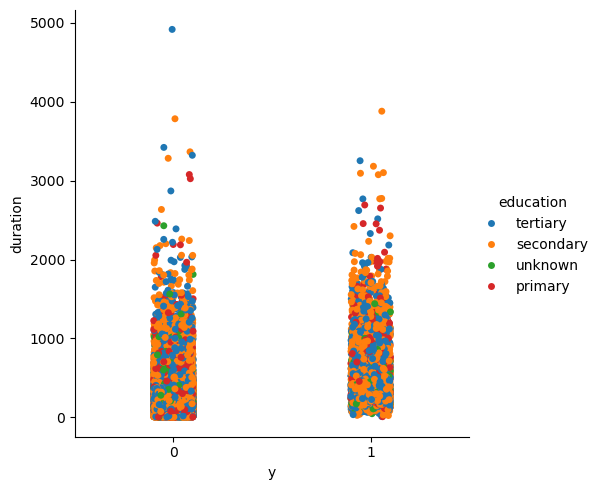

In [16]:
sns.catplot(data=df,x="y",y="duration",hue="education")

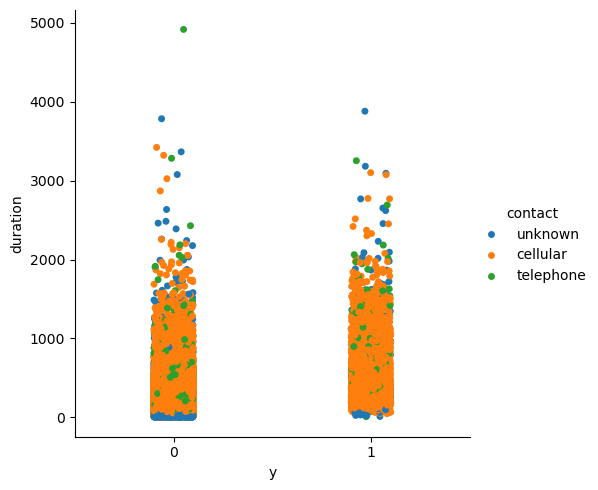

In [17]:
sns.catplot(data=df, x="y", y="duration", hue="contact")

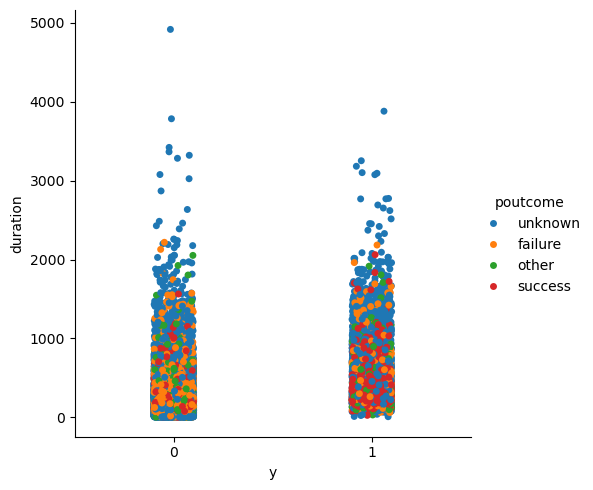

In [18]:
sns.catplot(data=df, x="y", y="duration", hue="poutcome")

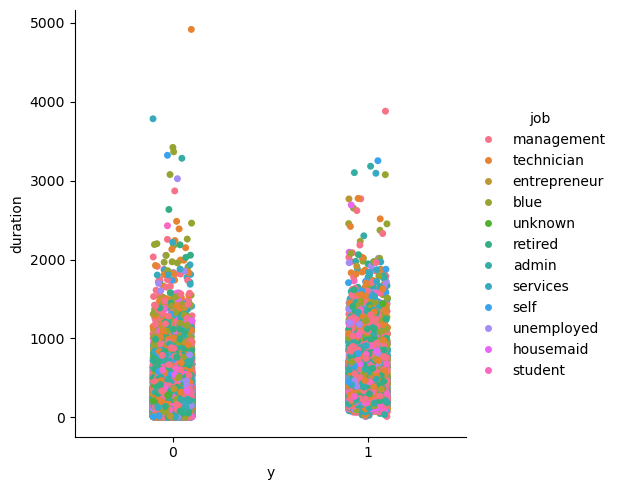

In [19]:
sns.catplot(data=df, x="y", y="duration", hue="job")

In [20]:
df = df[df["job"] != "unknown"] # job çok az oranda nan value sahip olduğu için o satırlar silindi
cat_col_number_of_unknown(df,columns_have_unknown)

job : 0
education : 1730
contact : 12909
poutcome : 36704


In [21]:
import math
def hist_of_columns(df, title_prefix=""):
    cols = df.select_dtypes(include=[np.number]).columns
    row_num = math.ceil(len(cols)/3)
    col_num = 3
    plt.figure(figsize=(5*col_num,4*row_num))
    for i,col in enumerate(cols,1):
        plt.subplot(row_num, col_num, i)
        sns.histplot(df[col], kde=True, bins=30)
        plt.title(f"{title_prefix} {col}")
        plt.xlabel("")
        plt.ylabel("")
    plt.tight_layout()
    plt.show()

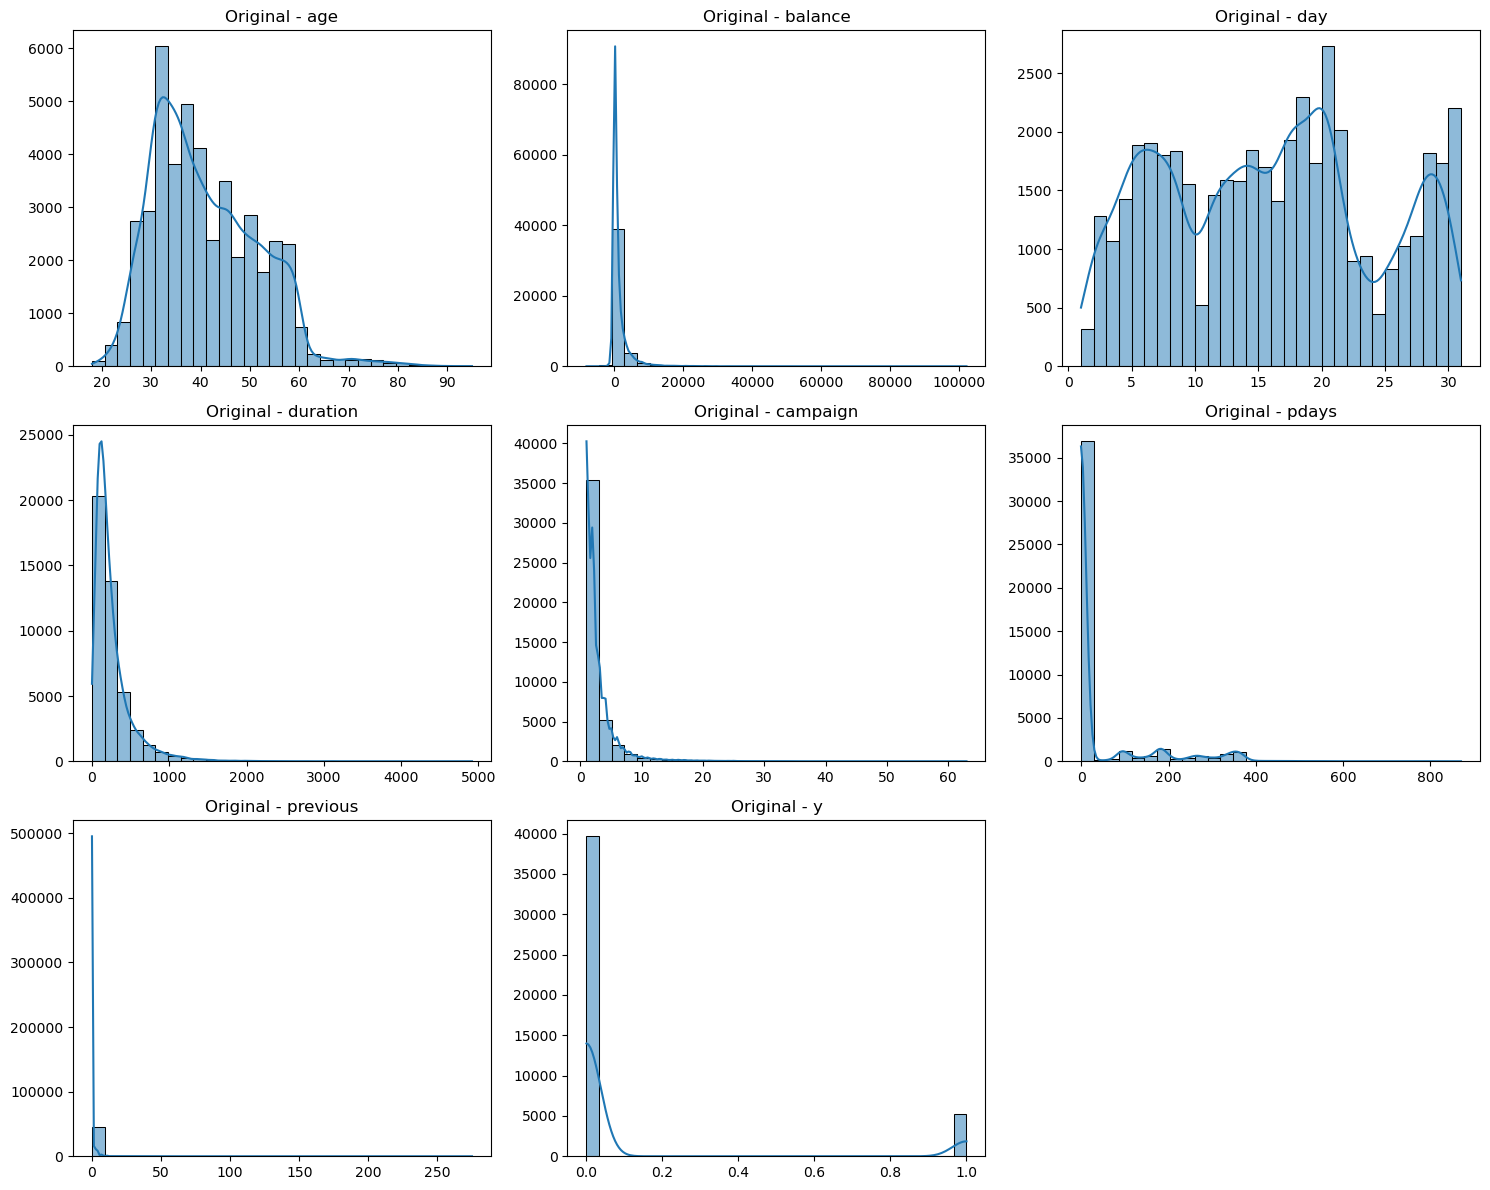

In [22]:
hist_of_columns(df,"Original -")

<Axes: ylabel='balance'>

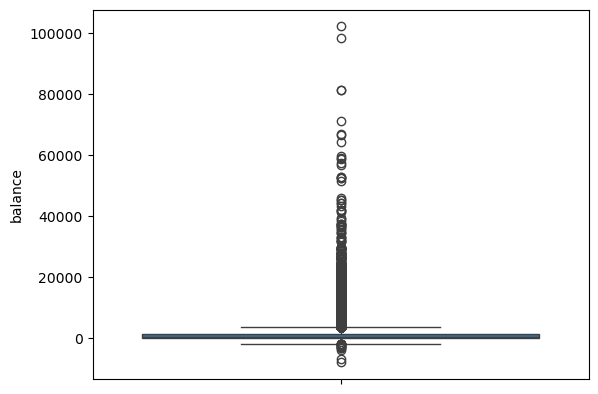

In [23]:
sns.boxplot(y=df["balance"])

In [24]:
def check_outliers(df, threshold): 
    cols = df.select_dtypes(include=["number"]).columns
    for col in cols:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)

        IQR = Q3-Q1
        down_bound = Q1 - threshold*IQR
        upper_bound = Q3 + threshold*IQR
        df = df[((df[col] >= down_bound) & (df[col] <= upper_bound))]   
    return df

In [25]:
df.shape

(44923, 17)

In [26]:
df_outliers_droped = check_outliers(df, 3)

In [27]:
df_outliers_droped.shape

(29989, 17)

In [28]:
df["previous_contact"] = (df["poutcome"] != "unknown").astype(int) # bir yeni kolon eklendi , kampanya yapılıp yapılmadığı ile ilgili

In [29]:
df["previous_contact"].value_counts()

previous_contact
0    36704
1     8219
Name: count, dtype: int64

In [30]:
pd.crosstab(df["contact"], df["y"], normalize="index") # importance dusuk gözüküyor, silmeden önce modellerle test et

y,0,1
contact,,
cellular,0.851067,0.148933
telephone,0.865385,0.134615
unknown,0.959098,0.040902


In [31]:
df["contact"].value_counts()

contact
cellular     29154
unknown      12909
telephone     2860
Name: count, dtype: int64

In [32]:
pd.crosstab(df["poutcome"],df["y"], normalize="index") # importance yüksek olabilir, silmeden once modellerle test et

y,0,1
poutcome,,
failure,0.874616,0.125384
other,0.833515,0.166485
success,0.354000,0.646000
unknown,0.908239,0.091761


In [33]:
pd.crosstab(df["job"], df["y"], normalize="index") # importance orta gibi, silmeden önce modellerle test et

y,0,1
job,,
admin,0.877973,0.122027
blue,0.927250,0.072750
entrepreneur,0.917283,0.082717
housemaid,0.912097,0.087903
management,0.862444,0.137556
retired,0.772085,0.227915
self,0.881571,0.118429
services,0.911170,0.088830
student,0.713220,0.286780


In [34]:
pd.crosstab(df["education"], df["y"], normalize="index") #importance düşük gibi görünüyor

y,0,1
education,,
primary,0.913529,0.086471
secondary,0.894471,0.105529
tertiary,0.849796,0.150204
unknown,0.864740,0.135260


In [35]:
(df[df["education"] == "unknown"].shape[0]/df.shape[0])*100 # yaklasık %4 ü nan veri yani mode ile dolduracağım

3.8510339914965606

In [36]:
df["education"].mode()[0]

'secondary'

In [37]:
df["education"] = df["education"].replace("unknown", df["education"].mode()[0])

In [38]:
is_cat_cols_have_unknown(df) # bu ikisine modelleri test ettikten sonra ve önce olarak bakacağım

['contact', 'poutcome']

In [39]:
def num_cols_unique_values(df):
    columns = df.select_dtypes(include=["int64"]).columns
    for col in columns:
        print(f"{col} : {df[col].unique()}")
        print("number of unique: ",len(list(df[col].unique())))
        print("\n")

In [40]:
def is_num_cols_have_unknown(df):
    cols = list()
    columns = df.select_dtypes(include=["int64"]).columns
    for col in columns:
        if "unknown" in list(df[col].unique()):
           cols.append(col)
    return cols

In [41]:
num_cols_unique_values(df)

age : [58 44 33 47 35 28 42 43 41 29 53 57 51 45 60 56 32 25 40 39 52 46 36 49
 59 37 50 54 55 48 24 38 31 30 27 34 23 26 61 22 21 20 66 62 83 75 67 70
 65 68 64 69 72 71 19 76 85 63 90 82 73 74 78 80 94 79 77 86 95 81 18 89
 84 87 92 93 88]
number of unique:  77


balance : [ 2143    29     2 ...  8205 14204 16353]
number of unique:  7142


day : [ 5  6  7  8  9 12 13 14 15 16 19 20 21 23 26 27 28 29 30  2  3  4 11 17
 18 24 25  1 10 22 31]
number of unique:  31


duration : [ 261  151   76 ... 1298 1246 1556]
number of unique:  1571


campaign : [ 1  2  3  5  4  6  7  8  9 10 11 12 13 19 14 24 16 32 18 22 15 17 25 21
 43 51 63 41 26 28 55 50 38 23 20 29 31 37 30 46 27 58 33 35 34 36 39 44]
number of unique:  48


pdays : [ -1 151 166  91  86 143 147  89 140 176 101 174 170 167 195 165 129 188
 196 172 118 119 104 171 117 164 132 131 123 159 186 111 115 116 173 178
 110 152  96 103 150 175 193 181 185 154 145 138 126 180 109 158 168  97
 182 127 130 194 125 105 102  26 179  28 183 155

In [42]:
is_num_cols_have_unknown(df) # numeric kolonlarda hiç nan value gözükmüyor

[]

In [43]:
#encoding

In [44]:
def encoding_yes_no_cols(cols):
    for col in cols:
        df[col] = df[col].replace("yes", 1)
        df[col] = df[col].replace("no", 0)

In [45]:
encoding_yes_no_cols(["housing","loan","default"])

In [46]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 44923 entries, 0 to 45210
Data columns (total 18 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   age               44923 non-null  int64 
 1   job               44923 non-null  object
 2   marital           44923 non-null  object
 3   education         44923 non-null  object
 4   default           44923 non-null  int64 
 5   balance           44923 non-null  int64 
 6   housing           44923 non-null  int64 
 7   loan              44923 non-null  int64 
 8   contact           44923 non-null  object
 9   day               44923 non-null  int64 
 10  month             44923 non-null  object
 11  duration          44923 non-null  int64 
 12  campaign          44923 non-null  int64 
 13  pdays             44923 non-null  int64 
 14  previous          44923 non-null  int64 
 15  poutcome          44923 non-null  object
 16  y                 44923 non-null  int64 
 17  previous_contact 

In [47]:
#education->label encoding | job, poutcome, marital,poutcome, contact, month-> onehot encoding

In [48]:
df["education"].value_counts()

education
secondary    24861
tertiary     13262
primary       6800
Name: count, dtype: int64

In [49]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [50]:
X = df.drop("y", axis=1)
y = df["y"]

In [51]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=15)

In [52]:
scaler=StandardScaler()

In [53]:
X_train.columns

Index(['age', 'job', 'marital', 'education', 'default', 'balance', 'housing',
       'loan', 'contact', 'day', 'month', 'duration', 'campaign', 'pdays',
       'previous', 'poutcome', 'previous_contact'],
      dtype='object')

In [54]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, PowerTransformer

In [55]:
ct = ColumnTransformer(transformers=[
                        ("cat", OneHotEncoder(), ["job", "poutcome", "marital","poutcome", "contact", "month"]),
                        ("ord", OrdinalEncoder(), ["education"])
                       ]
                       ,remainder="passthrough"
                      )

In [56]:
X_train_transformed = ct.fit_transform(X_train)
X_test_transformed = ct.transform(X_test)

In [57]:
pt_X = PowerTransformer(method="yeo-johnson")

In [58]:
column_names = ct.get_feature_names_out()

In [59]:
X_train = pd.DataFrame(X_train_transformed, columns=column_names)

In [60]:
X_test = pd.DataFrame(X_test_transformed, columns=column_names)

In [61]:
X_test.head()

,cat__job_admin,cat__job_blue,cat__job_entrepreneur,cat__job_housemaid,cat__job_management,cat__job_retired,cat__job_self,cat__job_services,cat__job_student,cat__job_technician,...,remainder__default,remainder__balance,remainder__housing,remainder__loan,remainder__day,remainder__duration,remainder__campaign,remainder__pdays,remainder__previous,remainder__previous_contact
0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,377.0,0.0,1.0,20.0,11.0,5.0,-1.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,2300.0,0.0,0.0,8.0,160.0,6.0,-1.0,0.0,0.0
2,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1214.0,1.0,0.0,2.0,150.0,2.0,189.0,2.0,1.0
3,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,816.0,0.0,0.0,19.0,630.0,1.0,-1.0,0.0,0.0
4,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,-872.0,1.0,1.0,3.0,267.0,1.0,-1.0,0.0,0.0


In [62]:
X_train.head()

,cat__job_admin,cat__job_blue,cat__job_entrepreneur,cat__job_housemaid,cat__job_management,cat__job_retired,cat__job_self,cat__job_services,cat__job_student,cat__job_technician,...,remainder__default,remainder__balance,remainder__housing,remainder__loan,remainder__day,remainder__duration,remainder__campaign,remainder__pdays,remainder__previous,remainder__previous_contact
0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,8873.0,1.0,0.0,19.0,172.0,1.0,118.0,2.0,1.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,1281.0,0.0,0.0,30.0,109.0,1.0,-1.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,1239.0,1.0,0.0,5.0,60.0,2.0,347.0,1.0,1.0
3,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,50.0,1.0,0.0,7.0,246.0,2.0,-1.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,354.0,0.0,1.0,22.0,186.0,2.0,-1.0,0.0,0.0


In [63]:
X_test.corr()

,cat__job_admin,cat__job_blue,cat__job_entrepreneur,cat__job_housemaid,cat__job_management,cat__job_retired,cat__job_self,cat__job_services,cat__job_student,cat__job_technician,...,remainder__default,remainder__balance,remainder__housing,remainder__loan,remainder__day,remainder__duration,remainder__campaign,remainder__pdays,remainder__previous,remainder__previous_contact
cat__job_admin,1.000000,-0.187641,-0.065640,-0.057888,-0.187940,-0.083481,-0.071007,-0.117654,-0.053188,-0.162043,...,-0.013564,-0.031381,0.038308,0.030990,-0.004480,-0.014340,-0.018990,0.006665,0.006624,0.009974
cat__job_blue,-0.187641,1.000000,-0.094666,-0.083487,-0.271050,-0.120398,-0.102408,-0.169682,-0.076708,-0.233701,...,0.014491,-0.055145,0.176619,0.018325,-0.027572,0.015364,0.013373,0.016134,-0.021862,-0.029639
cat__job_entrepreneur,-0.065640,-0.094666,1.000000,-0.029205,-0.094817,-0.042117,-0.035824,-0.059357,-0.026833,-0.081752,...,0.026311,0.014861,0.020560,0.047204,-0.006870,0.000724,0.021158,-0.003446,0.001709,-0.005266
cat__job_housemaid,-0.057888,-0.083487,-0.029205,1.000000,-0.083620,-0.037143,-0.031593,-0.052347,-0.023665,-0.072097,...,-0.003805,0.014549,-0.086098,-0.024322,0.006206,-0.014100,-0.004857,-0.044070,-0.013932,-0.039299
cat__job_management,-0.187940,-0.271050,-0.094817,-0.083620,1.000000,-0.120590,-0.102571,-0.169953,-0.076830,-0.234073,...,-0.007375,0.067579,-0.072803,-0.042403,0.015179,-0.003945,0.026040,-0.013388,0.025279,0.009632
cat__job_retired,-0.083481,-0.120398,-0.042117,-0.037143,-0.120590,1.000000,-0.045561,-0.075491,-0.034127,-0.103973,...,-0.008907,0.045661,-0.168313,-0.023656,-0.011873,0.030910,-0.040221,-0.010085,0.000660,0.017036
cat__job_self,-0.071007,-0.102408,-0.035824,-0.031593,-0.102571,-0.045561,1.000000,-0.064211,-0.029028,-0.088437,...,0.009961,0.017874,-0.032079,-0.009346,-0.015261,0.016143,-0.000860,0.001547,0.004676,0.009890
cat__job_services,-0.117654,-0.169682,-0.059357,-0.052347,-0.169953,-0.075491,-0.064211,1.000000,-0.048097,-0.146534,...,0.000799,-0.037102,0.085535,0.041566,0.013646,-0.007957,0.004598,0.021397,-0.008526,-0.000074
cat__job_student,-0.053188,-0.076708,-0.026833,-0.023665,-0.076830,-0.034127,-0.029028,-0.048097,1.000000,-0.066243,...,-0.014814,0.014050,-0.086994,-0.055453,-0.014626,-0.017943,-0.020772,0.034417,0.006552,0.040114
cat__job_technician,-0.162043,-0.233701,-0.081752,-0.072097,-0.234073,-0.103973,-0.088437,-0.146534,-0.066243,1.000000,...,-0.004713,-0.010949,-0.015490,0.009636,0.027324,-0.013656,0.004282,-0.008230,0.000267,0.004350


In [64]:
X_train.corr()

,cat__job_admin,cat__job_blue,cat__job_entrepreneur,cat__job_housemaid,cat__job_management,cat__job_retired,cat__job_self,cat__job_services,cat__job_student,cat__job_technician,...,remainder__default,remainder__balance,remainder__housing,remainder__loan,remainder__day,remainder__duration,remainder__campaign,remainder__pdays,remainder__previous,remainder__previous_contact
cat__job_admin,1.000000,-0.190342,-0.067093,-0.061699,-0.185692,-0.082957,-0.068103,-0.114277,-0.052495,-0.162936,...,-0.009174,-0.024832,0.041982,0.029541,-0.012936,-0.016503,-0.022490,0.033981,0.018659,0.030821
cat__job_blue,-0.190342,1.000000,-0.098181,-0.090287,-0.271733,-0.121395,-0.099659,-0.167226,-0.076819,-0.238433,...,0.008645,-0.046252,0.174700,0.016509,-0.022183,0.007396,0.008388,0.020601,-0.015902,-0.020608
cat__job_entrepreneur,-0.067093,-0.098181,1.000000,-0.031825,-0.095783,-0.042790,-0.035129,-0.058945,-0.027078,-0.084045,...,0.026174,0.008128,0.005940,0.036823,-0.001098,-0.002137,-0.004071,-0.018071,-0.014081,-0.018372
cat__job_housemaid,-0.061699,-0.090287,-0.031825,1.000000,-0.088081,-0.039350,-0.032304,-0.054206,-0.024901,-0.077287,...,0.000531,-0.002347,-0.079034,-0.015679,0.002952,-0.006232,0.006083,-0.027682,-0.016838,-0.022235
cat__job_management,-0.185692,-0.271733,-0.095783,-0.088081,1.000000,-0.118430,-0.097224,-0.163141,-0.074942,-0.232608,...,-0.001471,0.068855,-0.064782,-0.039560,0.019863,-0.010227,0.014270,-0.006899,0.016707,0.014418
cat__job_retired,-0.082957,-0.121395,-0.042790,-0.039350,-0.118430,1.000000,-0.043434,-0.072883,-0.033480,-0.103917,...,-0.012246,0.047812,-0.155423,-0.012739,-0.009846,0.024292,-0.027514,-0.005443,0.008648,0.019866
cat__job_self,-0.068103,-0.099659,-0.035129,-0.032304,-0.097224,-0.043434,1.000000,-0.059832,-0.027485,-0.085310,...,0.002046,0.018166,-0.027388,-0.008003,0.012003,0.004158,0.008052,-0.014873,-0.006737,-0.006760
cat__job_services,-0.114277,-0.167226,-0.058945,-0.054206,-0.163141,-0.072883,-0.059832,1.000000,-0.046120,-0.143149,...,-0.000366,-0.038302,0.063098,0.032570,-0.013747,0.004473,-0.007612,-0.000210,-0.013143,-0.014384
cat__job_student,-0.052495,-0.076819,-0.027078,-0.024901,-0.074942,-0.033480,-0.027485,-0.046120,1.000000,-0.065759,...,-0.016812,-0.003060,-0.086047,-0.060084,-0.016553,-0.002681,-0.022126,0.020933,0.033837,0.047530
cat__job_technician,-0.162936,-0.238433,-0.084045,-0.077287,-0.232608,-0.103917,-0.085310,-0.143149,-0.065759,1.000000,...,-0.002901,-0.017548,-0.015622,0.014984,0.033863,-0.007999,0.027351,-0.016013,-0.002444,-0.011459


In [65]:
# korelasyonların oranlarının kontrolü ve outlierslar kontrolü gerekli
X_train["remainder__duration"].quantile(0.50)

np.float64(181.0)

In [66]:
X_train["cat__job_admin"].corr(other=X_train["cat__job_blue"])

np.float64(-0.19034217072960902)

In [67]:
def check_on_corr(df, threshold): #sütunların korelasyon oranlarını kontrol eder
    cols_to_drop = set()
    columns = X_train.columns
    for i in range(len(columns)):   
        for j in range(i):
            if (abs(df[columns[i]].corr(other=df[columns[j]])) > threshold):
                print(df[columns[i]].corr(other=df[columns[j]]), " ", columns[i], " ", columns[j])
                cols_to_drop.add(columns[i])
    return cols_to_drop

In [68]:
X_train.columns[X_train.columns.duplicated()]

Index(['cat__poutcome_failure', 'cat__poutcome_other', 'cat__poutcome_success',
       'cat__poutcome_unknown'],
      dtype='object')

In [69]:
X_test.columns[X_test.columns.duplicated()]

Index(['cat__poutcome_failure', 'cat__poutcome_other', 'cat__poutcome_success',
       'cat__poutcome_unknown'],
      dtype='object')

In [70]:
X_train = X_train.loc[:,~X_train.columns.duplicated()]

In [71]:
X_test = X_test.loc[:,~X_test.columns.duplicated()]

In [72]:
X_train.rename(columns={"remainder_housing":"cat__housing", "remainder__loan":"cat__loan", "remainder__default":"cat__default"}, inplace=True)

In [73]:
X_test.rename(columns={"remainder_housing":"cat__housing", "remainder__loan":"cat__loan", "remainder__default":"cat__default"}, inplace=True)

In [74]:
check_on_corr(X_train, 0.85) #cat_poutcome_unknown silinebilir veya remainder_previous_contact

-0.8633712224736838   cat__contact_unknown   cat__contact_cellular
-0.8690738381281791   remainder__pdays   cat__poutcome_unknown
-1.0   remainder__previous_contact   cat__poutcome_unknown
0.8690738381281792   remainder__previous_contact   remainder__pdays


{'cat__contact_unknown', 'remainder__pdays', 'remainder__previous_contact'}

In [75]:
check_on_corr(X_test,0.85)#cat_poutcome_unknown silinebilir veya remainder_previous_contact

-0.8635708627959361   cat__contact_unknown   cat__contact_cellular
-0.8735269867911362   remainder__pdays   cat__poutcome_unknown
-1.0   remainder__previous_contact   cat__poutcome_unknown
0.8735269867911359   remainder__previous_contact   remainder__pdays


{'cat__contact_unknown', 'remainder__pdays', 'remainder__previous_contact'}

In [76]:
X_train.drop(["remainder__pdays","cat__contact_cellular","cat__poutcome_unknown"],axis=1, inplace=True)
X_test.drop(["remainder__pdays","cat__contact_cellular","cat__poutcome_unknown"],axis=1, inplace=True)

In [77]:
X_train.skew(numeric_only = True)

cat__job_admin                  2.412172
cat__job_blue                   1.367075
cat__job_entrepreneur           5.189634
cat__job_housemaid              5.674613
cat__job_management             1.427415
cat__job_retired                4.117667
cat__job_self                   5.107133
cat__job_services               2.839265
cat__job_student                6.724991
cat__job_technician             1.761781
cat__job_unemployed             5.567478
cat__poutcome_failure           2.507184
cat__poutcome_other             4.667035
cat__poutcome_success           5.207585
cat__marital_divorced           2.404887
cat__marital_married           -0.414432
cat__marital_single             0.963646
cat__contact_telephone          3.576444
cat__contact_unknown            0.943949
cat__month_apr                  3.490055
cat__month_aug                  2.103418
cat__month_dec                 14.837450
cat__month_feb                  3.760318
cat__month_jan                  5.399346
cat__month_jul  

In [78]:
# model learning ---> Logistic Regression, SVC, DesicionTreeClassifier, RandomForestClassifer,XGBoostClassifier,LightGBMClassifier, KNNClassifier,Naive Bayes

In [79]:
X_train_transformed = pt_X.fit_transform(X_train)
X_test_transformed = pt_X.transform(X_test)

In [93]:
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import AdaBoostClassifier,RandomForestClassifier,GradientBoostingClassifier
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report
import lightgbm as lgb
from xgboost import XGBClassifier

In [106]:
from sklearn.utils import compute_sample_weight

In [107]:
sample_weights = compute_sample_weight(class_weight="balanced", y=y_train)

In [108]:
clf = lgb.LGBMClassifier(verbosity=-1,class_weight="balanced")
xgb = XGBClassifier(n_estimators=100, class_weight="balanced")

In [109]:
y_train[y_train[y==0]].shape[0]/y_train.shape[0]

0.8837706280422652

In [114]:
def train_all_classification_models(X_train, y_train, X_test, y_test):
    base = DecisionTreeClassifier(max_depth=1, class_weight="balanced")
    models = {"LogisticRegression":LogisticRegression(class_weight="balanced"), "SVC":SVC(class_weight="balanced"),"DecisionTreeClassifier":DecisionTreeClassifier(class_weight="balanced",max_depth=8, min_samples_leaf=5, random_state=42),"AdaBoostClassifier":AdaBoostClassifier(estimator=base),"RandomForestClassifier":RandomForestClassifier(class_weight="balanced",n_estimators=200,
    max_depth=10,
    min_samples_leaf=5,
    random_state=42),"GradientBoostingClassifer":GradientBoostingClassifier(),"XGBClassifier":xgb,"LGBMClassifier":clf}
    for name,model in models.items():
        if(name=="GradientBoostingClassifier"):
            model.fit(X_train, y_train, sample_weight = sample_weights)
        else:
            model.fit(X_train, y_train)
        y_pred_train = model.predict(X_train)
        y_pred_test = model.predict(X_test)
        print(f"{name}\n")
        print("----------Training--------------")
        print("Accuracy Score: ", accuracy_score(y_train, y_pred_train))
        print("Confusion Matrix:\n", confusion_matrix(y_train, y_pred_train))
        print("Classification Report:\n", classification_report(y_train, y_pred_train))
        print("----------Testing--------------")
        print("Accuracy Score: ", accuracy_score(y_test, y_pred_test))
        print("Confusion Matrix:\n ", confusion_matrix(y_test, y_pred_test))
        print("Classification Report:\n", classification_report(y_test, y_pred_test))
        print("\n")

In [115]:
train_all_classification_models(X_train_transformed, y_train, X_test_transformed, y_test)

LogisticRegression

----------Training--------------
Accuracy Score:  0.8291285765166805
Confusion Matrix:
 [[24618  5158]
 [  599  3317]]
Classification Report:
               precision    recall  f1-score   support

           0       0.98      0.83      0.90     29776
           1       0.39      0.85      0.54      3916

    accuracy                           0.83     33692
   macro avg       0.68      0.84      0.72     33692
weighted avg       0.91      0.83      0.85     33692

----------Testing--------------
Accuracy Score:  0.8249488024218681
Confusion Matrix:
  [[8146 1746]
 [ 220 1119]]
Classification Report:
               precision    recall  f1-score   support

           0       0.97      0.82      0.89      9892
           1       0.39      0.84      0.53      1339

    accuracy                           0.82     11231
   macro avg       0.68      0.83      0.71     11231
weighted avg       0.90      0.82      0.85     11231



SVC

----------Training--------------
Accu

In [116]:
#hyperparameter tuning

In [117]:
params = {"LogisticRegression":{
                "penalty":["l2","none"],
                "C":[0.01,0.1,1,10,100],
                "solver":["lbfgs","liblinear"],
                "class_weight":["balanced",None],
                "max_iter":[100, 500, 1000]
            },
          "SVC":{
              "C":[0.01,0.1,1,10,100],
              "kernel":["linear","poly","rbf","sigmoid"],
              "degree":[2,3,4],
              "gamma":["scale","auto"],
              "class_weight":["balanced",None],
              "probability":[True]
          },
          "DecisionTreeClassifier":{
              "criterion":["gini","entropy"],
              "max_depth":[None, 5, 10, 15, 20],
              "min_samples_split":[2,5,10],
              "min_samples_leaf" :[1,2,5,10],
              "max_features":[None, "sqrt","log2"],
              "class_weight":["balanced",None]
          },
          "AdaBoostClassifer":{
              "n_estimators":[50, 100, 200],
              "learning_rate":[0.01,0.1,0.5,1],
              "algortihm":["SAMME","SAMME.R"]
              # base_estimator parametresi sklearn >=1.2'de estimator olarak verilmeli
          },
          "RandomForestClassifier":{
              "n_estimators":[100, 200, 500],
              "criterion":["gini","entropy"],
              "max_depth":[None, 5, 10, 15],
              "min_samples_split":[2, 5, 10],
              "min_samples_leaf":[1,2, 5],
              "max_features":["sqrt","log2",None],
              "class_weight":["balanced",None]
          },
          "GradientBoostingClassifier":{
                "n_estimators": [100, 200, 500],
                "learning_rate": [0.01, 0.05, 0.1, 0.2],
                "max_depth": [3, 5, 7, 10],
                "min_samples_split": [2, 5, 10],
                "min_samples_leaf": [1, 2, 5],
                "subsample": [0.6, 0.8, 1.0],
                "max_features": [None, "sqrt", "log2"]
          },
          "XGBClassifier":{
               "n_estimators": [100, 200, 500],
                "learning_rate": [0.01, 0.05, 0.1, 0.2],
                "max_depth": [3, 5, 7, 10],
                "subsample": [0.6, 0.8, 1.0],
                "colsample_bytree": [0.6, 0.8, 1.0],
                "gamma": [0, 0.1, 0.3, 0.5],
                "scale_pos_weight": [1, 5, 10]
          },
          "LGBMClassifier":{
                "n_estimators": [100, 200, 500],
                "learning_rate": [0.01, 0.05, 0.1, 0.2],
                "num_leaves": [31, 50, 70, 100],
                "max_depth": [-1, 5, 10, 15],
                "min_child_samples": [10, 20, 50],
                "subsample": [0.6, 0.8, 1.0],
                "colsample_bytree": [0.6, 0.8, 1.0],
                "class_weight": [None, "balanced"]
          }
          
         }

In [119]:
from sklearn.model_selection import RandomizedSearchCV

In [123]:
def train_all_classification_models_hyperparamter(X_train, y_train, X_test, y_test):
    base = DecisionTreeClassifier(max_depth=1, class_weight="balanced")
    models = {"LogisticRegression":LogisticRegression(class_weight="balanced"), "SVC":SVC(class_weight="balanced"),"DecisionTreeClassifier":DecisionTreeClassifier(),"AdaBoostClassifier":AdaBoostClassifier(estimator=base),"RandomForestClassifier":RandomForestClassifier(class_weight="balanced",n_estimators=200,
    max_depth=10,
    min_samples_leaf=5,
    random_state=42),"GradientBoostingClassifer":GradientBoostingClassifier(),"XGBClassifier":xgb,"LGBMClassifier":clf}
    for name,model in models.items():
        rcv = RandomizedSearchCV(model, param_distributions=params[name], n_iter=10, cv=5, scoring="f1")
        if(name=="GradientBoostingClassifier"):
            rcv.fit(X_train, y_train, sample_weight = sample_weights)
        else:
            rcv.fit(X_train, y_train)
        y_pred_train = rcv.predict(X_train)
        y_pred_test = rcv.predict(X_test)
        print(f"{name}\n")
        print("----------Training--------------")
        print("Accuracy Score: ", accuracy_score(y_train, y_pred_train))
        print("Confusion Matrix:\n", confusion_matrix(y_train, y_pred_train))
        print("Classification Report:\n", classification_report(y_train, y_pred_train))
        print("----------Testing--------------")
        print("Accuracy Score: ", accuracy_score(y_test, y_pred_test))
        print("Confusion Matrix:\n ", confusion_matrix(y_test, y_pred_test))
        print("Classification Report:\n", classification_report(y_test, y_pred_test))
        print("\n")

In [ ]:
train_all_classification_models_hyperparamter(X_train, y_train, X_test, y_test)

LogisticRegression

----------Training--------------
Accuracy Score:  0.8450670782381574
Confusion Matrix:
 [[25259  4517]
 [  703  3213]]
Classification Report:
               precision    recall  f1-score   support

           0       0.97      0.85      0.91     29776
           1       0.42      0.82      0.55      3916

    accuracy                           0.85     33692
   macro avg       0.69      0.83      0.73     33692
weighted avg       0.91      0.85      0.87     33692

----------Testing--------------
Accuracy Score:  0.8434689698156888
Confusion Matrix:
  [[8373 1519]
 [ 239 1100]]
Classification Report:
               precision    recall  f1-score   support

           0       0.97      0.85      0.90      9892
           1       0.42      0.82      0.56      1339

    accuracy                           0.84     11231
   macro avg       0.70      0.83      0.73     11231
weighted avg       0.91      0.84      0.86     11231



